In [5]:
from langgraph.graph import StateGraph, START, MessagesState,END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [6]:
load_dotenv()

True

In [7]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [8]:
def chat(state:MessagesState):
    response = model.invoke(state['messages'])
    return {"messages":[response]}

def delete_old_msg(state:MessagesState):
    msgs = state['messages']

    if len(msgs)>10:
        to_remove = msgs[:6]
        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}

In [9]:
builder = StateGraph(MessagesState)

builder.add_node("chat",chat)
builder.add_node("cleanup",delete_old_msg)

builder.add_edge(START,"chat")
builder.add_edge("chat","cleanup")
builder.add_edge("cleanup",END)

In [10]:
graph = builder.compile(checkpointer=InMemorySaver())

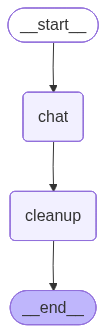

In [11]:
graph

In [12]:
config = {"configurable":{"thread_id":"thread-1"}}

In [13]:
graph.invoke({"messages":[{"role":"user","content":"Hi, I'm Nitish"}]},config=config)
graph.invoke({"messages":[{"role":"user","content":"Tell me about langgraph"}]},config=config)
graph.invoke({"messages":[{"role":"user","content":"Now explain checkpointer"}]},config=config)
graph.invoke({"messages":[{"role":"user","content":"what is langchain"}]},config=config)
graph.invoke({"messages":[{"role":"user","content":"what is quantum mechanics"}]},config=config)
graph.invoke({"messages":[{"role":"user","content":"what is gen ai"}]},config=config)
graph.invoke({"messages":[{"role":"user","content":"what is my name?"}]},config=config)

{'messages': [HumanMessage(content='what is langchain', additional_kwargs={}, response_metadata={}, id='9304a498-b65a-4be0-ab77-9bb2090def76'),
  AIMessage(content="**LangChain** is a Python library for building and deploying conversational AI applications, particularly those that involve natural language processing (NLP) and artificial intelligence (AI). It provides a flexible and modular framework for creating conversational interfaces, enabling developers to build custom chatbots, virtual assistants, and other conversational AI systems.\n\n**Key features of LangChain**:\n\n1. **Modular architecture**: LangChain is designed to be modular, allowing developers to easily switch between different NLP models, AI engines, and other components.\n2. **Conversational interface**: LangChain provides a simple and intuitive API for building conversational interfaces, making it easy to create chatbots and virtual assistants.\n3. **Integration with popular libraries**: LangChain supports integrati